# S. Appendix

### S.1 Additional Experimental Setups

In this study, the model design and training process followed the research procedures described in previous studies [1,2]. To ensure fair comparisons among all experiments, a consistent network architecture and training configuration were maintained across all methods. Unless otherwise specified, the Physics-Informed Deep Operator Network model comprises a Trunk Network, a Branch Network, and a Gating Network, each containing five hidden layers with 256 neurons per layer and employing the GELU activation function. The network parameters were initialized using the default scheme in PyTorch.

The loss function follows the PIDoN formulation, in which weights are assigned to the data-fitting, ODE residual, and initial condition terms. The experimental validation was performed by measuring the volumetric flowrate.

$$
\hat{q}(t) \approx G_\theta [v](t) \approx \psi(v,t;\theta^*)
\tag{S.1}
$$

$$
L_{\mathrm{Data}} = \frac{1}{N_t} \sum_{i=1}^{N_t} \left[\hat{q}(t_i)-q(t_i)\right]^2,
$$

$$
L_{\mathrm{Res}} = \frac{1}{N_t} \sum_{i=1}^{N_t} \left[\left\{L\ddot{q}(t_i)+R\dot{q}(t_i)+\frac{1}{C}q(t_i)\right\}-F U_A(t_i)\right]^2,
$$

$$
L_{\mathrm{Init}} = \left[q(t_0)-0\right]^2 + \left[L\dot{q}(t_0)-0\right]^2
\tag{S.2}
$$

The total loss is defined as:

$$
L_{\mathrm{Tot}} = \lambda_{\mathrm{Data}} L_{\mathrm{Data}} + \lambda_{\mathrm{Res}} L_{\mathrm{Res}} + \lambda_{\mathrm{Init}} L_{\mathrm{Init}}
\tag{S.3}
$$

where $L_{\mathrm{Data}}$, $L_{\mathrm{Res}}$, and $L_{\mathrm{Init}}$ represent the mean squared errors corresponding to the training data, ODE residual, and initial condition, respectively. To adequately enforce the data-fitting constraint, the weighting factors were set to $\lambda_{\mathrm{Data}} = 10^6$, $\lambda_{\mathrm{Res}} = 10^6$, and $\lambda_{\mathrm{Init}} = 10^3$. The optimization was performed using the Adam optimizer with an applied learning-rate scheduling strategy. The data sampling was conducted using a PIDoN mesh-free approach, employing collocation points distributed throughout the entire computational domain. For the time-dependent problem, the training data were measured at 1 $\mu$s intervals over a total duration of 300 $\mu$s. The ODE residual was also evaluated through temporal sampling over the same time interval. To enforce the initial condition, collocation points were sampled at $t_0 = 0$ to impose the initial condition.

In this section, we provide a detailed description of the Deep Operator Network (DoN) architecture, a systematic methodology for domain-specific feature extraction, parameter initialization, normalization techniques, and the overall operational workflow. The integrated PIDoN model is designed to solve the ODE by incorporating learnable feature mappings and domain-specific knowledge into the neural network framework. To ensure statistical significance, each parameter identification was repeated five times with different random seeds.

The DoN employed in this study consists of three primary components: the Branch Network, the Trunk Network, and an auxiliary Gating Network. The architecture is summarized as follows:

- **Branch Network:** 5 hidden layers, each with 256 neurons and GELU activation, mapping input parameters to a latent representation.
- **Trunk Network:** 5 hidden layers, each with 256 neurons and GELU activation, mapping temporal input to a latent representation.
- **Gating Network:** 5 hidden layers, each with 256 neurons and GELU activation, followed by a sigmoid activation to provide gating modulation over the latent space.
- **Latent Dimension:** Each network outputs a latent vector of dimension 32.
- **Output Layer:** The final operator output is obtained by an element-wise product of Branch, Trunk, and Gating Network outputs, followed by summation and a learnable bias term.

---



### Appendix S.2 Bayesian Optimization Framework

The optimization problem considered in this study aims to identify the design variable that minimizes the evaluation cost, represented by the objective function $J(x)$. The optimal design variable is defined as

$$
x^{*} = \arg\min_{x \in \mathbb{R}^{D}} J(x)
\tag{S.4}
$$

where $x$ denotes the $D$-dimensional design vector, $J(x)$ is the unknown objective function, and $x^{*}$ represents the global minimizer.

To quantify the uncertainty of the objective function, a Gaussian process (GP) was adopted. For an arbitrary input set $\{x_1, \ldots, x_n\}$, the function values $(J(x_1), \ldots, J(x_n))$ are assumed to follow a multivariate normal distribution governed by the mean function $m(x)$ and covariance function $k(x,x')$:

$$
J(x) \sim GP\!\left(m(x), k(x,x')\right)
\tag{S.5}
$$

where $GP$ denotes the Gaussian process, $m(x)$ is the mean function, and $k(x,x')$ is the covariance function. Accordingly, the Gaussian process prior in Eq. (S.5) was constructed as a surrogate model for optimizing $J(x)$ defined in Eq. (S.4).

Because the observed response $y_i$ includes measurement error, the dataset associated with the design variable vector $x_i$ was defined by incorporating the observation noise $\varepsilon_i$ into the GP formulation:

$$
D_j = \{(x_i, y_i)\}_{i=1}^{j}, \qquad
y_i = J(x_i) + \varepsilon_i, \qquad
\varepsilon_i \sim \mathcal{N}(0, V_n^2)
\tag{S.6}
$$

where $D_j$ denotes the set of $j$ observations, $V_n^2$ is the noise variance, and $\mathcal{N}$ denotes the normal distribution. This implies that the observation error $\varepsilon_i$ follows a Gaussian distribution with zero mean and variance $V_n^2$.

To perform Gaussian process prediction, the posterior mean was formulated by combining the GP prior in Eq. (S.5) with the dataset $D_j$ in Eq. (S.6):

$$
M_j(x) = k_j(x)^{\top} \left(K_j + V_n^2 I\right)^{-1} y_j
\tag{S.7}
$$

where $M_j(x)$ is the posterior mean and $K_j$ is the kernel matrix formed from $k(x_i, x_j)$.

To quantify the reduction in uncertainty at the next prediction step, the posterior variance was defined as

$$
V_j^2(x) = k(x,x) - k_j(x)^{\top}\left(K_j + V_n^2 I\right)^{-1} k_j(x)
\tag{S.8}
$$

where $V_j^2(x)$ denotes the posterior variance and $k(x,x)$ denotes the prior variance. Equation (S.8) indicates that the prior variance is retained in regions distant from the sampled points, whereas uncertainty is reduced near previously observed points.

In Bayesian optimization, the objective function and the acquisition function play critical roles. To define a reference for improvement-based criteria such as Expected Improvement (EI) and Probability of Improvement (PI), the current best observed value is defined as

$$
J_{\mathrm{best}} = \min_{i \le j} y_i
\tag{S.9}
$$

Using the posterior mean $M_j(x)$ from Eq. (S.7) and the posterior standard deviation $V_j(x) = \sqrt{V_j^2(x)}$, the expected improvement is written as

$$
EI_j(x) = \left(J_{\mathrm{best}} - M_j(x)\right)\Psi(z) + V_j(x)\phi(z),
\qquad
z = \frac{J_{\mathrm{best}} - M_j(x)}{V_j(x)}
\tag{S.10}
$$

where $\Psi$ and $\phi$ denote the cumulative distribution function (CDF) and probability density function (PDF) of the standard normal distribution, respectively, and $z$ is the normalized improvement. The next point is selected by maximizing the expected improvement.

Similarly, the probability of improvement at iteration $j$ is given by

$$
PI_j(x) = \Psi\!\left(\frac{J_{\mathrm{best}} - M_j(x)}{V_j(x)}\right)
\tag{S.11}
$$

which represents the probability that the candidate point will improve upon the current best value.

For minimization of the objective function, the lower confidence bound (LCB) acquisition function was also considered:

$$
LCB_j(x) = M_j(x) - \sqrt{b_j}\,V_j(x)
\tag{S.12}
$$

where $b_j$ is the exploration parameter. This acquisition function balances exploitation and exploration through the uncertainty term.

To optimize the acquisition function, the next sampling point was selected by solving

$$
x_{j+1} = \arg\min_x a_j(x),
\qquad
a_j \in \{EI, PI, LCB\}
\tag{S.13}
$$

After selecting the next point, the corresponding observation was obtained by evaluating the objective function:

$$
y_{j+1} = J(x_{j+1}) + \varepsilon_{j+1}
\tag{S.14}
$$

where $\varepsilon_{j+1}$ denotes the new observation noise.

The newly selected data pair $(x_{j+1}, y_{j+1})$ was then appended to the dataset, and the posterior distribution was updated according to

$$
D_{j+1} = D_j \cup \{(x_{j+1}, y_{j+1})\}
\tag{S.15}
$$

where $D_{j+1}$ denotes the updated dataset.

The hyperparameters $\theta$ of the Gaussian process substantially influence the performance of Bayesian optimization. In this study, the covariance function in Eq. (S.5) was modeled using the radial basis function (RBF) kernel, which determines similarity according to the distance between two input points. The hyperparameters consist of the length scale $l$, output variance $V_J^2$, and noise variance $V_n^2$, and they were optimized by maximizing the log marginal likelihood:

$$
\theta^{*} = \arg\min_{\theta} \log p(y_j \mid X_j, \theta),
\qquad
\theta = \{V_J^2, l, V_n^2\}
\tag{S.16}
$$

where $l$ controls the sensitivity to the distance between inputs, $V_J^2$ denotes the output scale of the function, and $V_n^2$ represents the observation noise variance.

The RBF kernel employed in this study is expressed as

$$
k_{SE}(x,x') = V_J^2 \exp\!\left(-\frac{\|x-x'\|^2}{2l^2}\right)
\tag{S.17}
$$

This kernel is used to form both the kernel matrix $K_j(\theta)$ and the kernel vector $k_j(\theta)$ required for the posterior mean and variance in Eqs. (S.7) and (S.8).

Once the dataset is updated, the posterior mean and posterior variance are renewed as

$$
\left(M_{j+1}(x), V_{j+1}^2(x)\right)
\tag{S.18}
$$

and the corresponding acquisition value is evaluated by

$$
a_j(x) = J\!\left(M_j(x), V_j(x)\right)
\tag{S.19}
$$

where $a_j$ denotes the acquisition function based on EI, PI, or LCB.

The stopping criterion terminates the iterative optimization when either the maximum number of evaluations is reached or the improvement falls below a prescribed tolerance:

$$
(t \le N_{\max}) \,\vee\, \left(\left|J_{\mathrm{best}}^{(j)} - J_{\mathrm{best}}^{(j-1)}\right| < E\right)
\tag{S.20}
$$

where $\vee$ denotes the logical OR operator, $N_{\max}$ is the maximum number of allowable iterations, and $E$ is the convergence tolerance.

The cumulative regret is defined as the accumulated discrepancy between the observed objective values and the global optimum over $N$ evaluations. When the exploration parameter $b_t$ is appropriately chosen, the cumulative regret decreases progressively, thereby ensuring global convergence:

$$
E_j = \sum_{j=1}^{N} \left(J(x_j) - J^{*}\right) = O\!\left(\sqrt{N \log N}\right),
\qquad
(GP\text{-}LCB,\; b_j \propto \log j)
\tag{S.21}
$$

where $E_j$ denotes the cumulative regret.

Finally, the optimal design can be selected either by the minimum observed response or by the global minimum of the GP posterior mean:

$$
x_{BO}^{*} = \arg\min_{i \le J} y_i
$$

$$
x_{BO}^{*} = \arg\min_x M(x),
\qquad
V_J(x) \to 0
\tag{S.22}
$$

where $x_{BO}^{*}$ denotes the optimal operating condition proposed by Bayesian optimization. In the present study, this corresponds to the voltage condition. Consequently, Bayesian optimization provides not only the optimal condition but also a global surrogate model that can be further utilized for sensitivity analysis, experimental design, and multi-objective extension.

---


### S.3 PIDoN-Coupled Surrogate Modeling for Bayesian Optimization

In the subsequent stage, the Physics-Informed Deep Operator Network (PIDoN) was coupled with Bayesian optimization as the surrogate model. The PIDoN receives the input vector and predicts the flow-rate waveform:

$$
q_{\theta}(x_1, x_2) = NN_{\theta}([x_1, x_2])
\tag{S.23}
$$

with

$$
x_1 \in \mathbb{R}^{6},
\qquad
x_1 = [\mu, \sigma, \rho, c, p_{\mathrm{Supply}}, t_{\mathrm{Pinch}}]
$$

and

$$
x_2 \in \mathbb{R}^{300},
\qquad
x_2 = [v_1, v_2, \ldots, v_{299}, v_{300}]
$$

where $q$ denotes the flow-rate vector, $NN_{\theta}$ denotes the Physics-Informed Deep Operator Neural Network, and $x_1$ and $x_2$ represent the operating conditions and voltage-waveform features, respectively.

Unlike previous studies focused on direct parameter identification, the present framework was designed such that the parameters $R$, $L$, and $C$ were determined whenever the flow-rate prediction was performed from the operating conditions and feature data. In addition, the external input $U_d$ was formulated by additionally considering the supply pressure. The damping coefficient $\alpha_{\mathrm{damp}} = R/(2L)$, damping ratio $\xi = R/(2\sqrt{C/L})$, and natural frequency $\omega_n = 1/\sqrt{LC}$ are determined from the physical parameters $R$, $L$, and $C$, and together define the exponential decay envelope $q_{\mathrm{env}}(t)$ for quantitative vibration analysis:

$$
R = \frac{2\mu l}{\pi \delta_v r^3},
\qquad
L = \frac{\rho l}{\pi r^2},
\qquad
C = \frac{\pi r^2 l}{c^2 \rho}
\tag{S.24}
$$

$$
U_d = \left(\frac{\rho c^2 \alpha \times 2}{r}\right)\frac{dV(t)}{dt}
+
\frac{\pi r^4 \Delta P_{\mathrm{Supply}}}{8\mu l}
\tag{S.25}
$$

$$
U_d = L\frac{d^2 q}{dt^2} + R\frac{dq}{dt} + \frac{1}{C}q
\tag{S.26}
$$

$$
q_{\mathrm{env}}(t) = A_{\mathrm{env}}\,q_{\mathrm{env},0}\,e^{-\alpha_{\mathrm{damp}}\xi\omega_n t}
\tag{S.27}
$$

where $A_{\mathrm{env}}$ is the amplitude correction factor introduced to improve accuracy.

In piezoelectric inkjet systems, the onset of residual vibration is defined as the time immediately after droplet pinch-off. Since the flow rate appears as an oscillatory waveform, the decay behavior was quantified using the decay-envelope amplitudes at the pinch-off time $t_{\mathrm{Pinch}}$ and the final time $t_{\mathrm{fin}}$:

$$
\left(r_{\mathrm{Pinch}}(x), r_{\mathrm{Fin}}(x)\right)
=
\left(
\left|q_{\theta}(x)_{t_{\mathrm{Pinch}}}\right|,
\left|q_{\theta}(x)_{t_{\mathrm{fin}}}\right|
\right)
\tag{S.28}
$$

Using the amplitudes defined above, the nondimensional decay metric was defined as

$$
\Lambda^{*}(x) = \ln\!\left(\frac{r_{\mathrm{Fin}}(x)}{r_{\mathrm{Pinch}}(x)}\right)
\tag{S.29}
$$

and the Bayesian optimization objective was set as

$$
J(x) = \Lambda^{*}(x)
\tag{S.30}
$$

Following the same GP-based surrogate construction described above, the posterior model was formulated for the objective function:

$$
J(x) \sim GP\!\left(m(x), k(x,x')\right)
\tag{S.31}
$$

At each new point $x_{i+1}$, the corresponding observation was obtained as

$$
y_i = J(x_i) + \varepsilon_i,
\qquad
\varepsilon_i \sim \mathcal{N}(0, V_n^2)
\tag{S.32}
$$

and the dataset was updated iteratively, as in Eqs. (S.14) and (S.15), followed by repeated Bayesian optimization based on the posterior update in Eq. (S.18).

Finally, the next point was selected by minimizing the acquisition function:

$$
x_{t+1} = \arg\min_x a_t(x),
\qquad
a_t \in \{EI, PI, LCB\}
\tag{S.33}
$$

Through this framework, the present study proposes a decay-rate-based analysis method driven by the derived physical parameters $R$, $L$, and $C$ under varying physical variables such as viscosity, density, speed of sound, and nozzle radius. Because this metric reflects the physical causal relationship among the voltage condition, operating variables, and flow-rate waveform, it can serve as an optimization objective directly linked to practical design variables. Moreover, the proposed exponential-decay-based metric exhibits high correlation with the satellite-droplet generation condition and therefore provides a useful indicator for ensuring stable and repeatable droplet ejection in inkjet applications.

---
---

# Data acquisition

In this study, the experimentally measured interfacial displacement was obtained to secure the data acquisition. To ensure the reliability of the physical trends, physical validation was performed under the same conditions as those used in the experiments. The configuration of the experimental measurement system is presented below.

<div align="center">
  <img src="Fig 1..jpg" alt="Experiment setup" width="1000"><br>
  Fig. 1. Experimental setup: (a) actual experimental system and (b) schematic diagram of the experimental procedure.
</div>

- The developed Extended Bayesian Optimization model predicts the volumetric flow rate and real-time decay rate based on the ink properties, voltage waveform, and operating conditions.

- For this purpose, six types of ethylene glycol (EG) were used in the experiments to define the ink property conditions.

- The volumetric flow rate was determined by measuring the flow displacement at the nozzle interface under driving voltages ranging from 20 to 40 V.

- This approach enabled the establishment of precise operating conditions by validating the physical trends observed in the actual experiments.

<div align="center">
  <b>Table 1.</b> Physical property conditions of the piezoelectric inkjet
</div>

<div align="center">

| EG     | Surface tension, $\sigma$ [N/m] | Dynamic viscosity, $\mu$ [Pa·s] | Density, $\rho$ [kg/m³] | Piezoelectric coefficient, $\alpha$ [m/V] | Speed of sound, $c$ [m/s] |
| ------ | ------------------------------: | ------------------------------: | ----------------------: | ----------------------------------------: | ------------------------: |
| EG 100 |                          0.0474 |                          0.0157 |                 1114.00 |                                  2.90e-10 |                   1688.00 |
| EG 90  |                          0.0497 |                          0.0105 |                 1101.00 |                                  2.90e-10 |                   1688.00 |
| EG 75  |                          0.0521 |                          0.0064 |                 1081.00 |                                  2.90e-10 |                   1709.38 |
| EG 65  |                          0.0539 |                          0.0049 |                 1070.00 |                                  2.90e-10 |                   1707.98 |
| EG 60  |                          0.0551 |                          0.0041 |                 1072.00 |                                  2.90e-10 |                   1703.27 |
| EG 50  |                          0.0565 |                          0.0030 |                 1056.00 |                                  2.90e-10 |                   1638.21 |

</div>


<div align="center">
  <img src="Fig 2..jpg" alt="Voltage waveform condition" width="1200"><br>
  Fig 2. Voltage waveform condition
</div>

In [17]:
# ═════════════ Voltage waveform feature dataset ─══════════════════════════
# ────────────────────────────────────────────────────────────
# Import libraries & set base paths
# ────────────────────────────────────────────────────────────
import pandas as pd
import re                       # (Not used directly below, but commonly
                                #  imported for regex work; kept for clarity)

#base_dir  = r"D:\lsy_DL\Oscilation"     # Working directory
#raw_csv   = fr"{base_dir}\0. Feature data_PIDoN4.csv"   # Source CSV file
#out_csv   = fr"{base_dir}\0. Feature data_withID.csv"  # Destination CSV file

base_dir  = r"D:\Code review\0. Training data"     # Working directory
raw_csv   = fr"{base_dir}\0. Feature data_Bayesian.csv"   # Source CSV file
out_csv   = fr"{base_dir}\0. Feature data_withID.csv"  # Destination CSV file



df = pd.read_csv(raw_csv)       # Read source data into a DataFrame

# ────────────────────────────────────────────────────────────
# Create a new column 'waveform_id'
#    Goal: convert strings like "30 voltage waveform" → "v30"
#    Steps:
#      ① Extract numeric part with regex r"(\d+)"
#      ② Cast to integer (optional but convenient)
#      ③ Prepend the letter 'v' to obtain the final ID
# ────────────────────────────────────────────────────────────
df["waveform_id"] = (
    df["V_name"]                       # target text column
    .str.extract(r"(\d+)", expand=False)   # ① extract digits only
    .astype(int)                          # ② convert to integer
    .apply(lambda x: f"v{x}")             # ③ add 'v' prefix → "v30"
)

df = df.drop(columns=["V_name"])
df.to_csv(out_csv, index=False)
print(f"✔  waveform_id created and saved →  {out_csv}")


✔  waveform_id created and saved →  D:\Code review\0. Training data\0. Feature data_withID.csv


In [12]:
# ═════════════ Ink property feature dataset ─══════════════════════════
#csv_path = r"D:\lsy_DL\Oscilation\0. Feature data_withID.csv"
csv_path = r"D:\Code review\0. Training data\0. Feature data_withID.csv"
df = pd.read_csv(csv_path)
print(df.head(3))
print(df.shape)


      mu   sigma   rho     c    t  v1        v2        v3  v4         v5  ...  \
0  15.76  0.0474  1114  1688  118   0  3.333333  6.666667  10  13.333333  ...   
1  15.76  0.0474  1114  1688  121   0  3.666667  7.333333  11  14.666667  ...   
2  15.76  0.0474  1114  1688  122   0  4.000000  8.000000  12  16.000000  ...   

   v292  v293  v294  v295  v296  v297  v298  v299  v300  waveform_id  
0     0     0     0     0     0     0     0     0     0          v20  
1     0     0     0     0     0     0     0     0     0          v22  
2     0     0     0     0     0     0     0     0     0          v24  

[3 rows x 306 columns]
(11, 306)


In [18]:
# ═════════════ Volumetric flowrate target dataset ─══════════════════════════
tgt_path = r"D:\Code review\0. Training data\0. Target data_Bayesian.csv"
target_df = pd.read_csv(tgt_path)
print(target_df.head(1))
print(target_df.shape)

         q1        q2        q3        q4        q5        q6        q7  \
0  0.000001  0.000001  0.000001  0.000001  0.000001  0.000001  0.000001   

         q8        q9       q10  ...      q291      q292      q293      q294  \
0  0.000001  0.000001  0.000001  ...  0.000001  0.000001  0.000001  0.000001   

       q295      q296      q297      q298      q299      q300  
0  0.000001  0.000001  0.000001  0.000001  0.000001  0.000001  

[1 rows x 300 columns]
(11, 300)


In [15]:
import pandas as pd
import torch

# ────────────────────────────────
# Load feature data
# ────────────────────────────────
#csv_path = r"D:\lsy_DL\Oscilation\0. Feature data_withID.csv"
csv_path = r"D:\Code review\0. Training data\0. Feature data_withID.csv"
df = pd.read_csv(csv_path)
print("전체 shape:", df.shape)

# ────────────────────────────────
# 1. X1 = scalar physical parameters
# ────────────────────────────────
scalar_cols = ['mu', 'sigma', 'rho', 'c', 't']
X1 = df[scalar_cols].copy()
print("X1 shape:", X1.shape)

# ────────────────────────────────
# 2. X2 = voltage waveform vectors (v1 ~ v300)
# ────────────────────────────────
vec_cols = [c for c in df.columns if c.startswith("v") and c[1:].isdigit()]
X2 = df[vec_cols].copy()
print("X2 shape:", X2.shape)

# ────────────────────────────────
# 3. waveform_id
# ────────────────────────────────
waveform_id = df[['waveform_id']].copy()
print("waveform_id shape:", waveform_id.shape)

# ────────────────────────────────
# Convert to torch tensors 
# ────────────────────────────────
X1_t = torch.tensor(X1.values, dtype=torch.float32)
X2_t = torch.tensor(X2.values, dtype=torch.float32)

print("Tensor X1:", X1_t.shape)
print("Tensor X2:", X2_t.shape)


전체 shape: (11, 306)
X1 shape: (11, 5)
X2 shape: (11, 300)
waveform_id shape: (11, 1)
Tensor X1: torch.Size([11, 5])
Tensor X2: torch.Size([11, 300])


In [16]:
import os, re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# ======================================================================
# 1) Load CSV files
# ======================================================================
base_dir  = r"D:\Code review\0. Training data" 
feat_csv  = fr"{base_dir}\features_Bayesian.csv"               # (66 × (5+1))
lib_csv   = fr"{base_dir}\waveforms_Bayesian.csv"              # (66 × (300+1))
tgt_csv   = fr"{base_dir}\targets_Bayesian_withID.csv"         # (66 × (300+1))

# Fixed scalar inputs: 5 variables (excluding p)
scalar_cols = ['mu','sigma','rho','c','t']

# Extract v1..v300 safely using a regex, then sort by the numeric index
lib_cols  = pd.read_csv(lib_csv, nrows=1).columns
vec_cols  = sorted([c for c in lib_cols if re.fullmatch(r'v\d+', c)],
                   key=lambda s: int(s[1:]))

# Target columns
q_cols    = [f"q{i}" for i in range(1,301)]

# Load data
feat_df = pd.read_csv(feat_csv)           # columns: scalar_cols + waveform_id
waves   = pd.read_csv(lib_csv)            # columns: waveform_id + v1..v300
tgt_df  = pd.read_csv(tgt_csv)            # columns: waveform_id + q1..q300

# Defensive reordering to guarantee column order consistency
waves = waves[['waveform_id'] + vec_cols]
missing_q = set(q_cols) - set(tgt_df.columns)
if missing_q:
    raise ValueError(f"targets file missing columns: {sorted(missing_q)}")
tgt_df = tgt_df[['waveform_id'] + q_cols]

# Merge tables with 1:1 matching while preserving 66 rows
df = (feat_df
      .merge(waves,  on='waveform_id', how='inner')
      .merge(tgt_df, on='waveform_id', how='inner'))

# Sort by the numeric part of waveform_id for reproducibility
df['_wid_num'] = df['waveform_id'].str.extract(r'(\d+)', expand=False).astype(int)
df = df.sort_values('_wid_num').drop(columns=['_wid_num'])

# Convert data to tensors
X1 = torch.tensor(df[scalar_cols].to_numpy(dtype=np.float32), dtype=torch.float32)  # [N, 5]
X2 = torch.tensor(df[vec_cols].to_numpy(dtype=np.float32),    dtype=torch.float32)  # [N, 300]
Y  = torch.tensor(df[q_cols].to_numpy(dtype=np.float32),      dtype=torch.float32)  # [N, 300]

print("X1.shape:", X1.shape)
print("X2.shape:", X2.shape)
print("Y.shape :", Y.shape)

# 300-point waveform library (dict): used for single-sample inference
# Use vec_cols to avoid dependence on raw column order
waves = pd.read_csv(lib_csv)
waves = waves[['waveform_id'] + vec_cols]
WAVE_DB = dict(zip(waves['waveform_id'], waves[vec_cols].to_numpy(dtype=np.float32)))

# Ground-truth library: used for prediction-to-target comparison
GT_DB = dict(zip(tgt_df['waveform_id'], tgt_df[q_cols].to_numpy(dtype=np.float32)))

# ======================================================================
# 3) Dataset
# ======================================================================
class RawSet(Dataset):
    def __init__(self, X1, X2, Y):
        self.X1, self.X2, self.Y = X1, X2, Y

    def __len__(self):  
        return len(self.Y)

    def __getitem__(self, i):
        return self.X1[i], self.X2[i], self.Y[i]

dataset = RawSet(X1, X2, Y)

X1.shape: torch.Size([11, 5])
X2.shape: torch.Size([11, 300])
Y.shape : torch.Size([11, 300])


---
---

# Hyperparameter tunning

In the present model, hyperparameter tuning was performed by varying the number of training data points, the number of collocation points, the learning rate, and the learning scheduler settings. In this study, the optimization procedure was initiated from the baseline hyperparameter conditions and subsequently refined through systematic validation. As a result, the best performance was obtained at 500 training points, 200 collocation points, and a learning rate of $1 \times 10^{-3}$. For the learning scheduler, the most favorable performance was observed within the range of $1 \times 10^{-4}$ to $1 \times 10^{-3}$. These findings indicate that variations in the tested hyperparameters had a substantial influence on the overall training error, suggesting that they constitute critical factors for achieving stable convergence of the model.

Accordingly, the final training conditions may be selected by jointly considering computational efficiency and implementation stability. However, under extended conditions, a reduction in reproducibility was observed.

<div align="center">
  <b>Table 2.</b> Validation of the total loss according to the number of training points.
</div>

<div align="center">

| Condition  | 200 | 300 | 400 | 500 | 600 |
|:----------:|:---:|:---:|:---:|:---:|:---:|
| Total loss | $1.72 \times 10^{6}$ | $5.25 \times 10^{6}$ | $4.25 \times 10^{5}$ | $2.25 \times 10^{5}$ | $6.32 \times 10^{5}$ |

</div>

<br>

<div align="center">
  <b>Table 3.</b> Validation of the total loss according to the number of collocation points.
</div>

<div align="center">

| Condition  | 200   | 300   | 400   | 500   | 600   |
|:----------:|:-----:|:-----:|:-----:|:-----:|:-----:|
| Total loss | $1.54 \times 10^{5}$ | $3.79 \times 10^{5}$ | $5.20 \times 10^{5}$ | $1.32 \times 10^{6}$ | $3.20 \times 10^{6}$ |

</div>

<br>

<div align="center">
  <b>Table 4.</b> Validation of the total loss according to the learning rate.
</div>

<div align="center">

| Condition  | $5 \times 10^{-3}$ | $1 \times 10^{-3}$ | $5 \times 10^{-4}$ | $1 \times 10^{-4}$ | $5 \times 10^{-5}$ |
|:----------:|:------------------:|:------------------:|:------------------:|:------------------:|:------------------:|
| Total loss | $2.32 \times 10^{5}$ | $1.20 \times 10^{5}$ | $1.25 \times 10^{5}$ | $4.25 \times 10^{5}$ | $5.25 \times 10^{6}$ |

</div>

<br>

<div align="center">
  <b>Table 5.</b> Validation of the total loss according to the scheduler setting.
</div>

<div align="center">

| Condition  | $5 \times 10^{-3}$ | $1 \times 10^{-3}$ | $5 \times 10^{-4}$ | $1 \times 10^{-4}$ | $5 \times 10^{-5}$ |
|:----------:|:------------------:|:------------------:|:------------------:|:------------------:|:------------------:|
| Total loss | $5.25 \times 10^{5}$ | $2.25 \times 10^{5}$ | $1.25 \times 10^{5}$ | $2.30 \times 10^{5}$ | $4.25 \times 10^{5}$ |

</div>

---
---

# Training & Prediction

대소 문자 확인

### Result 1. Hyperparameter tuning results: (a) Evolution of Total, Data, Residual, and Initial Losses; (b) Predicted volumetric flowrate under different operating voltages.

[   1] mean loss 6.859e+05 | data 6.859e-01 | pde 0.000e+00 | ic 0.000e+00
[ 200] mean loss 2.053e+04 | data 2.053e-02 | pde 1.284e-03 | ic 4.914e-08
[ 400] mean loss 1.415e+04 | data 1.415e-02 | pde 3.430e-03 | ic 3.948e-07
[ 600] mean loss 1.069e+04 | data 1.069e-02 | pde 5.812e-03 | ic 4.762e-07
[ 800] mean loss 8.931e+03 | data 8.931e-03 | pde 8.255e-03 | ic 6.916e-07
[1000] mean loss 8.192e+03 | data 8.192e-03 | pde 1.031e-02 | ic 8.068e-07
[1200] mean loss 7.938e+03 | data 7.938e-03 | pde 1.140e-02 | ic 5.958e-07
[1400] mean loss 7.784e+03 | data 7.784e-03 | pde 1.212e-02 | ic 6.537e-07
[1600] mean loss 7.241e+03 | data 7.241e-03 | pde 1.279e-02 | ic 2.952e-06
[1800] mean loss 6.839e+03 | data 6.839e-03 | pde 1.282e-02 | ic 6.501e-06
[2000] mean loss 6.646e+03 | data 6.646e-03 | pde 1.292e-02 | ic 7.012e-06
[2200] mean loss 7.152e+03 | data 7.152e-03 | pde 1.319e-02 | ic 1.698e-06
[2400] mean loss 5.316e+03 | data 5.316e-03 | pde 1.384e-02 | ic 8.021e-07
[2600] mean loss 5.151e+0

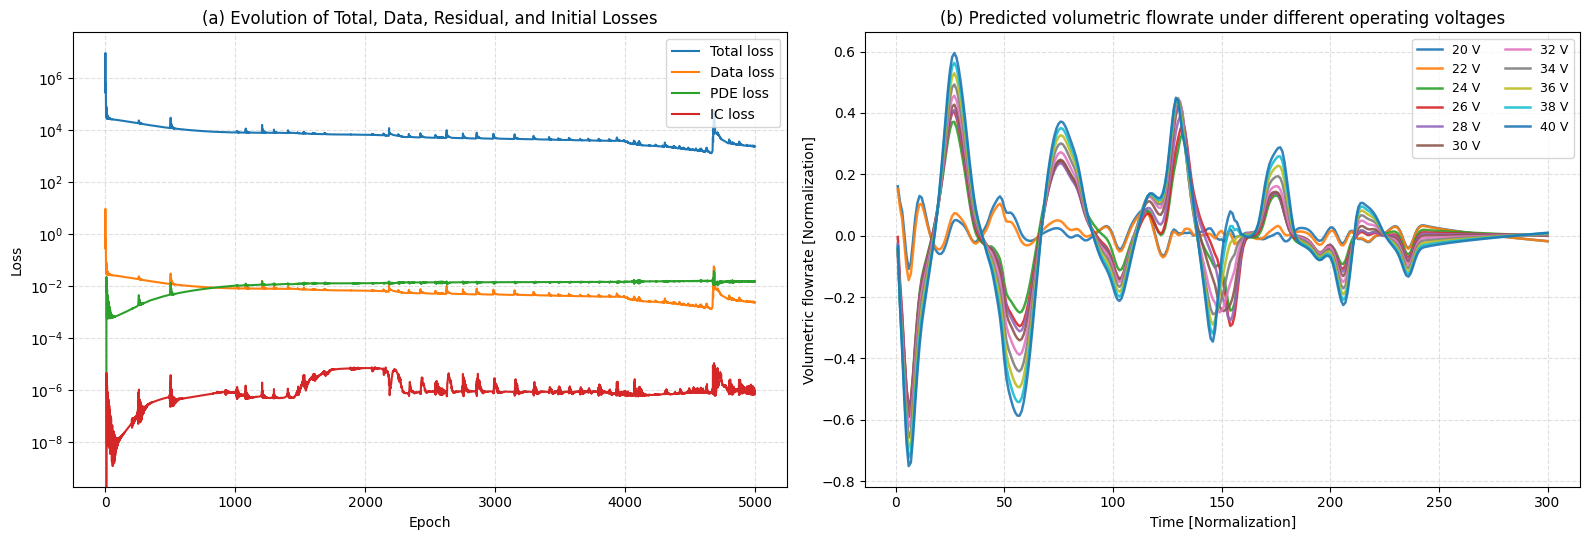

In [31]:
# ======================================================================
# 0) Imports
# ======================================================================
import math
import numpy as np                     
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt        

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
np.random.seed(42)

# ======================================================================
# 2) Constants and normalization factors
# ======================================================================
T_norm = torch.linspace(0, 1, 300)            # Normalized time grid (sequence length L=300)
dt      = (T_norm[1]-T_norm[0]).item()        # Time step = 1/299

# Normalization coefficients
# R_nd = R * R_Norm
# L_nd = L * L_Norm
# C_nd = C * C_Norm
# Ud_nd = Ud * Ud_Norm
# q_nd-related derivatives are scaled by Q_Norm
R_Norm, L_Norm, C_Norm = 1e-14, 1e-11, 1e16
Ud_Norm, Q_Norm        = 1e-8,  1e-2          # Normalization factors for forcing and flowrate

# ======================================================================
# 4) DeepONet
#   - Branch-1 input dimension: 5 ([mu, sigma, rho, c, t], excluding p)
# ======================================================================
def mlp(d_in, hid, d_out):
    layers, h_prev = [], d_in
    for h in hid:
        layers += [nn.Linear(h_prev, h), nn.GELU()]
        h_prev = h
    layers.append(nn.Linear(h_prev, d_out))
    return nn.Sequential(*layers)

class DeepONet(nn.Module):
    def __init__(self, seq_len=300, latent=256,
                 branch1_hid=[256, 256, 256, 256, 256, 256],      # 6 hidden layers
                 branch2_hid=[256, 256, 256, 256, 256, 256],      # 6 hidden layers
                 trunk_hid=[256, 256, 256, 256, 256, 256],        # 6 hidden layers
                 gate_hid=[256]*7):                               # 7 hidden layers
        super().__init__()

        self.branch1 = mlp(5,        branch1_hid, latent)   # Input: scalar features [mu, sigma, rho, c, t]
        self.branch2 = mlp(seq_len,  branch2_hid, latent)   # Input: waveform vector [v1, ..., v300]
        self.trunk   = mlp(1,        trunk_hid,   latent)   # Input: normalized time coordinate
        self.gate    = mlp(1,        gate_hid,    latent)   # Input: normalized time coordinate
        self.bias    = nn.Parameter(torch.zeros(1, seq_len))

        # Normalized time grid: t_i = i / L,  i = 1, ..., L
        t = torch.linspace(1, seq_len, seq_len).view(-1, 1) / seq_len
        self.register_buffer("t_grid", t)

    def forward(self, x1, x2):
        # x1: (B, 5), x2: (B, 300)
        # B(x) = Branch1(x1) + Branch2(x2)
        # T(t) = Trunk(t)
        # G(t) = sigmoid(Gate(t))
        # Output:
        #   q_hat(t) = B(x) · ( T(t) ⊙ G(t) ) + bias
        B = self.branch1(x1) + self.branch2(x2)     # (B, latent)
        T = self.trunk(self.t_grid)                 # (L, latent)
        G = torch.sigmoid(self.gate(self.t_grid))   # (L, latent)
        return B @ (T * G).T + self.bias            # (B, L=300)

# Initialize device and model
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = DeepONet().to(DEVICE)

# ======================================================================
# 5) Physics helper
#   - Scalar indexing: mu(0), sigma(1), rho(2), c(3), t(4)
# ======================================================================
def physics_terms(q, scal, v):
    # scal: (B, 5) = [mu, sigma, rho, c, t]
    mu     = scal[:, 0:1]
    sigma  = scal[:, 1:2]  # Currently unused in the present formulation; reserved for future extensions
    rho    = scal[:, 2:3]
    c      = scal[:, 3:4]
    t_pin  = scal[:, 4:5]  # Currently not used directly in the present formulation

    # Geometry and physical constants
    l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697
    L_tot          = l1 + l2 + l3 + l4
    r_ch           = 235e-6
    alpha_pzt      = 0.29e-9

    # Viscous time scale and boundary-layer thickness approximation
    # T_visc  = 2 * L_tot / c
    # delta_v = sqrt( mu * T_visc / (pi * rho) )
    T_visc  = 2 * L_tot / c
    delta_v = torch.sqrt(mu * T_visc / math.pi / rho)

    # Dimensionless physical coefficients
    # R_nd = [ 2 * mu * L_tot / (pi * delta_v * r_ch^3) ] * R_Norm
    # L_nd = [ rho * L_tot / (pi * r_ch^2) ] * L_Norm
    # C_nd = [ pi * r_ch^2 * L_tot / (c^2 * rho) ] * C_Norm
    R_nd = 2 * mu * L_tot / (math.pi * delta_v * r_ch**3) * R_Norm
    L_nd = rho * L_tot / (math.pi * r_ch**2)              * L_Norm
    C_nd = math.pi * r_ch**2 * L_tot / (c**2 * rho)       * C_Norm

    # Central-difference approximation on the interior points
    # dq/dt    ≈ (q_{i+1} - q_{i-1}) / (2*dt)
    # d2q/dt2  ≈ (q_{i-1} - 2q_i + q_{i+1}) / dt^2
    dq_nd  = (q[:, 2:] - q[:, :-2]) / (2 * dt) * Q_Norm
    d2q_nd = (q[:, :-2] - 2*q[:, 1:-1] + q[:, 2:]) / (dt**2) * Q_Norm
    q_mid  = q[:, 1:-1] * Q_Norm

    # Input forcing term
    # dV/dt   ≈ (v_{i+1} - v_{i-1}) / (2*dt)
    # Ud      = (rho * c^2 * alpha_pzt * 2 / r_ch) * dV/dt
    # Ud_nd   = Ud * Ud_Norm
    dVdt   = (v[:, 2:] - v[:, :-2]) / (2 * dt)
    Ud1    = (rho * c**2 * alpha_pzt * 2 / r_ch) * dVdt
    Ud_nd  = Ud1 * Ud_Norm

    return R_nd, L_nd, C_nd, Ud_nd, dq_nd, d2q_nd, q_mid

# ----------------------------------------------------------------------
# Loss functions
# ----------------------------------------------------------------------
def data_loss(q_pred, q_true):
    # Mean squared error:
    # L_data = mean( (q_pred - q_true)^2 )
    return torch.mean((q_pred - q_true).pow(2))

def pde_loss(q_pred, scal, v):
    # Governing residual:
    # Residual = L_nd * d2q/dt2 + R_nd * dq/dt + q / C_nd - Ud_nd
    # L_pde    = mean( Residual^2 )
    R_nd, L_nd, C_nd, Ud_nd, dq_nd, d2q_nd, q_mid = physics_terms(q_pred, scal, v)
    resid = L_nd * d2q_nd + R_nd * dq_nd + q_mid / C_nd - Ud_nd
    return torch.mean(resid.pow(2))

def ic_loss(q_pred, scal, v):
    # Initial-condition loss:
    # q(0) = 0
    # L_nd * dq/dt|_{t=0} = v(0)   (in the current normalized implementation)
    # L_ic = mean( q0^2 + (L_nd * dq0 - v0)^2 )
    _, L_nd, _, _, _, _, _ = physics_terms(q_pred, scal, v)
    q0_nd  = q_pred[:, 0] * Q_Norm
    dq0_nd = (q_pred[:, 1] - q_pred[:, 0]) / dt * Q_Norm
    v0_nd  = v[:, 0] * Ud_Norm
    return torch.mean(q0_nd.pow(2) + (L_nd.squeeze(-1) * dq0_nd - v0_nd).pow(2))

# ======================================================================
# 6) Training loop (+ history recording for visualization)
# ======================================================================
EPOCHS, PHYS_ON     = 5000, 10
DATA_W, PDE_W, IC_W = 1e6, 1e-2, 1e-2
loader   = DataLoader(dataset, batch_size=300, shuffle=True)
optim    = torch.optim.Adam(model.parameters(), lr=5e-4)

# Container for loss history
hist = {
    "epoch": [],
    "total": [],
    "data":  [],
    "pde":   [],
    "ic":    []
}

for ep in range(1, EPOCHS + 1):
    model.train()
    sum_tot = 0.0
    sum_d   = 0.0
    sum_p   = 0.0
    sum_i   = 0.0

    for x1, x2, y in loader:
        x1, x2, y = x1.to(DEVICE), x2.to(DEVICE), y.to(DEVICE)  # x1: (B, 5), x2: (B, 300), y: (B, 300)
        q_pred    = model(x1, x2)                                # Predicted output: (B, 300)

        l_d = data_loss(q_pred, y)
        if ep >= PHYS_ON:
            l_p = pde_loss(q_pred, x1, x2)
            l_i = ic_loss(q_pred, x1, x2)
        else:
            l_p = torch.tensor(0.0, device=DEVICE)
            l_i = torch.tensor(0.0, device=DEVICE)

        # Total loss:
        # L_total = DATA_W * L_data + PDE_W * L_pde + IC_W * L_ic
        loss = DATA_W * l_d + PDE_W * l_p + IC_W * l_i

        optim.zero_grad()
        loss.backward()
        optim.step()

        # Accumulate batch losses for epoch-wise averaging
        sum_tot += float(loss.detach())
        sum_d   += float(l_d.detach())
        sum_p   += float(l_p.detach())
        sum_i   += float(l_i.detach())

    # Record epoch-wise mean losses
    n_batch = len(loader)
    mean_tot = sum_tot / n_batch
    mean_d   = sum_d   / n_batch
    mean_p   = sum_p   / n_batch
    mean_i   = sum_i   / n_batch

    hist["epoch"].append(ep)
    hist["total"].append(mean_tot)
    hist["data"].append(mean_d)
    hist["pde"].append(mean_p)
    hist["ic"].append(mean_i)

    if ep == 1 or ep % 200 == 0:
        print(f"[{ep:4d}] mean loss {mean_tot:.3e} | data {mean_d:.3e} | pde {mean_p:.3e} | ic {mean_i:.3e}")

# ======================================================================
# 7) Visualization
# ======================================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))

ax[0].plot(hist["epoch"], hist["total"], label="Total loss")
ax[0].plot(hist["epoch"], hist["data"],  label="Data loss")
ax[0].plot(hist["epoch"], hist["pde"],   label="PDE loss")
ax[0].plot(hist["epoch"], hist["ic"],    label="IC loss")
ax[0].set_title("(a) Evolution of Total, Data, Residual, and Initial Losses")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_yscale("log")
ax[0].grid(True, which="both", linestyle="--", alpha=0.4)
ax[0].legend(loc="upper right")


model.eval()
with torch.no_grad():
    X1_all = X1.to(DEVICE)
    X2_all = X2.to(DEVICE)
    Y_all  = Y.to(DEVICE)
    Y_pred = model(X1_all, X2_all)

Y_pred_np = Y_pred.detach().cpu().numpy()
Y_true_np = Y_all.detach().cpu().numpy()

t_axis = np.arange(1, Y_pred_np.shape[1] + 1)
wave_ids = df["waveform_id"].tolist()

for i in range(Y_pred_np.shape[0]):
    voltage_label = f"{int(wave_ids[i][1:])} V"
    ax[1].plot(t_axis, Y_pred_np[i], linewidth=1.8, alpha=0.9, label=voltage_label)

ax[1].set_xlabel("Time [Normalization]")
ax[1].set_ylabel("Volumetric flowrate [Normalization]")
ax[1].set_title("(b) Predicted volumetric flowrate under different operating voltages")
ax[1].grid(True, linestyle="--", alpha=0.4)
ax[1].legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig("combined_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

### Result 2. Prediction decay rate: (a) prediction results, (b) phase trajectory, and (c) exponential decay rate

[Metrics @ v30]  MSE=5.567322e-04  MAE=1.561249e-02  Pearson r=0.9892


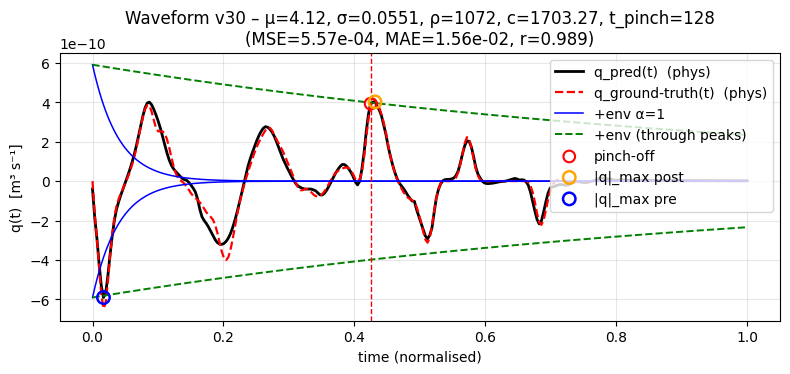

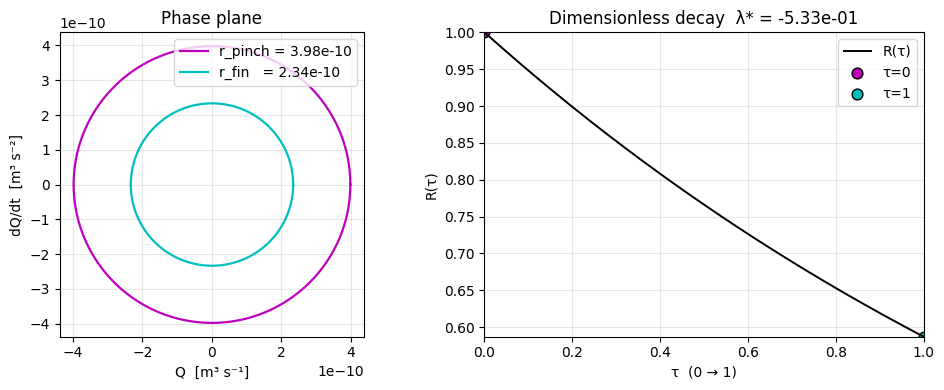

In [10]:
# ======================================================================
# 0) Imports & DEVICE ---------------------------------------------------
# ======================================================================
import math, os, numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ======================================================================
# 7) expo_decay (시각화용)  ← 스칼라 5개 체계로 수정 -------------------
# ======================================================================
def expo_decay(q_pred, scal_row, t_pinch_idx):
    """
    q_pred      : (300,) numpy  – 모델 예측(무차원 q)
    scal_row    : (5,)          – (μ, σ, ρ, c, t_pinch)
    t_pinch_idx : int           – 0-based pinch index (t_pinch-1)
    반환: dict (모든 좌표·envelope)
    """
    t_norm = np.linspace(0, 1, 300)
    q_arr  = q_pred.copy()

    idx_pin   = t_pinch_idx
    t_star    = t_norm[idx_pin]
    q_star    = q_arr[idx_pin]

    # post-pinch
    idx_amp = t_amp = q_amp = None
    if idx_pin+1 < len(q_arr):
        post_q    = q_arr[idx_pin+1:]
        idx_rel   = np.argmax(np.abs(post_q))
        idx_amp   = idx_pin+1+idx_rel
        t_amp, q_amp = t_norm[idx_amp], q_arr[idx_amp]

    # pre-pinch
    idx_pre = t_pre = q_pre = None
    if idx_pin > 0:
        pre_q   = q_arr[:idx_pin]
        idx_pre = np.argmax(np.abs(pre_q))
        t_pre, q_pre = t_norm[idx_pre], q_arr[idx_pre]

    # ------------------------------  물성 파생 파라미터 (예: 감쇠)  ------------------------------
    mu, sigma, rho, c, t_pinch = scal_row
    l1,l2,l3,l4 = 0.012, 0.0084, 0.00542303, 0.00057697
    L_tot, r_ch = l1+l2+l3+l4, 235e-6
    T_visc = 2*L_tot / c
    delta_v= math.sqrt(mu*T_visc/math.pi/rho)
    R = 2*mu*L_tot/(math.pi*delta_v*r_ch**3)
    L = rho*L_tot/(math.pi*r_ch**2)
    C = math.pi*r_ch**2*L_tot/(c**2*rho)

    zeta    = R / (2*math.sqrt(L/C))
    omega_n = 1.0 / math.sqrt(L*C)

    # ------------------------------  envelope & 물리 스케일 변환  ------------------------------
    scale = 1e-9
    q_phys = q_arr*scale
    t_s    = t_norm*300e-6
    A_env  = np.max(np.abs(q_phys))
    env_a1 =  A_env*np.exp(-1.0*zeta*omega_n*t_s)

    env_cust = None
    if (idx_pre is not None) and (idx_amp is not None):
        t_pre_s = t_pre*300e-6
        t_amp_s = t_amp*300e-6
        denom = (zeta*omega_n*(t_amp_s - t_pre_s))
        if denom != 0 and (abs(q_pre) > 0) and (abs(q_amp) > 0):
            alpha_c = (np.log(abs(q_pre*scale)/abs(q_amp*scale)) / denom)
            env_cust = A_env*np.exp(-alpha_c*zeta*omega_n*t_s)

    return dict(t=t_norm, q=q_phys,
                idx_pin=idx_pin, t_star=t_star, q_star=q_star*scale,
                idx_amp=idx_amp, t_amp=t_amp, q_amp=q_amp*scale if q_amp is not None else None,
                idx_pre=idx_pre, t_pre=t_pre, q_pre=q_pre*scale if q_pre is not None else None,
                env_a1=env_a1, env_cust=env_cust)

def decay_rate(env: dict):
    """
    env : expo_decay()가 돌려준 dict
    반환 : None  (env_cust가 없으면)  또는
           {lam_star, r_pinch, r_fin, tau, R_tau}
    """
    env_c = env["env_cust"]
    if env_c is None:
        return None

    idx_p   = env["idx_pin"]
    r_pinch = abs(env_c[idx_p])             # |q| at pinch (envelope 값)
    r_fin   = abs(env_c[-1])                # |q| at t_norm = 1

    t       = env["t"]
    tau     = (t - t[idx_p]) / (t[-1] - t[idx_p])     # 0 → 1
    R_tau   = env_c / r_pinch
    mask    = (tau >= 0) & (tau <= 1)
    tau_seg = tau[mask]
    R_seg   = R_tau[mask]

    lam_star = math.log(r_fin / r_pinch) if r_pinch > 0 and r_fin > 0 else float('nan')

    return dict(lam_star=lam_star,
                r_pinch=r_pinch, r_fin=r_fin,
                tau=tau_seg, R_tau=R_seg)

# ======================================================================
# 8) Exponential decay & visualization  +  GT(원 데이터) 비교 ----------
# ======================================================================
# 전처리 블록에서 생성한 사전들을 그대로 사용:
#   - WAVE_DB : waveform_id → v1..v300 (np.float32)
#   - GT_DB   : waveform_id → q1..q300 (np.float32)

# 예측 입력 구성 (★ x1/x2 분리 인덱스 5로 수정)
single = (4.12, 0.0551, 1072, 1703.27, 128, "v30")   # 5 scalars + id
mu, sigma, rho, c_val, t_pinch, wid = single

v_wave = WAVE_DB[wid]  # (300,)

x_np  = np.concatenate([[mu, sigma, rho, c_val, t_pinch], v_wave]).astype(np.float32)
x1_np, x2_np = x_np[:5], x_np[5:]

model.eval()
with torch.no_grad():
    q_out = model(torch.from_numpy(x1_np).unsqueeze(0).to(DEVICE),
                  torch.from_numpy(x2_np).unsqueeze(0).to(DEVICE)
                 ).squeeze(0).cpu().numpy()   # (300,)  — 예측(무차원)

# 정답(무차원) 불러오기
if wid not in GT_DB:
    raise KeyError(f"waveform_id {wid} not found in GT_DB.")
q_gt = GT_DB[wid].astype(np.float32)          # (300,) — 원래 Y (무차원)

# expo_decay는 내부에서 예측을 물리단위(×1e-9)로 변환하여 반환
ed = expo_decay(q_out, np.array([mu, sigma, rho, c_val, t_pinch], dtype=np.float64), t_pinch-1)

# 원 데이터도 같은 스케일(물리 단위)로 일관 변환
scale = 1e-9
q_gt_phys = q_gt * scale

# ------------------  정량 지표 ------------------
mse = float(np.mean((q_out - q_gt)**2))
mae = float(np.mean(np.abs(q_out - q_gt)))
# Pearson r: 분산 0 방지
if (np.std(q_out) > 0) and (np.std(q_gt) > 0):
    r = float(np.corrcoef(q_out, q_gt)[0,1])
else:
    r = np.nan

print(f"[Metrics @ {wid}]  MSE={mse:.6e}  MAE={mae:.6e}  Pearson r={r:.4f}")

# ------------------  시각화 (예측 vs 원데이터) ------------------
plt.figure(figsize=(8,4))
plt.plot(ed['t'], ed['q'], 'k', lw=2, label='q_pred(t)  (phys)')
plt.plot(ed['t'], q_gt_phys, 'r--', lw=1.6, label='q_ground-truth(t)  (phys)')
plt.plot(ed['t'],  ed['env_a1'], 'b-', lw=1.1, label='+env α=1')
plt.plot(ed['t'], -ed['env_a1'], 'b-', lw=1.1)

if ed['env_cust'] is not None:
    plt.plot(ed['t'],  ed['env_cust'], 'g--', lw=1.4, label='+env (through peaks)')
    plt.plot(ed['t'], -ed['env_cust'], 'g--', lw=1.4)

plt.axvline(ed['t_star'], color='red', ls='--', lw=1)
plt.scatter(ed['t_star'], ed['q_star'], s=70, facecolors='none',
            edgecolors='red', linewidths=1.5, zorder=3, label='pinch-off')

if ed['idx_amp'] is not None:
    plt.scatter(ed['t_amp'], ed['q_amp'], s=80, facecolors='none',
                edgecolors='orange', linewidths=1.8, zorder=3,
                label='|q|_max post')
if ed['idx_pre'] is not None:
    plt.scatter(ed['t_pre'], ed['q_pre'], s=80, facecolors='none',
                edgecolors='blue', linewidths=1.8, zorder=3,
                label='|q|_max pre')

plt.xlabel('time (normalised)')
plt.ylabel('q(t)  [m³ s⁻¹]')
plt.title(f"Waveform {wid} – μ={mu}, σ={sigma}, ρ={rho}, c={c_val}, t_pinch={t_pinch}\n"
          f"(MSE={mse:.2e}, MAE={mae:.2e}, r={r:.3f})")
plt.grid(alpha=.3); plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

# ======================================================================
# 9) Decay-rate ‧ phase-plane 시각화 -----------------------------------
# ======================================================================
dr = decay_rate(ed)
if dr is None:
    print("[skip] env_cust 없음 → λ* subplot 생략")
else:
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4))

    # (좌) phase plane : r_pinch, r_fin 원
    theta = np.linspace(0, 2*np.pi, 361)
    axL.plot(dr['r_pinch']*np.cos(theta), dr['r_pinch']*np.sin(theta),
             'm-', lw=1.6, label=f"r_pinch = {dr['r_pinch']:.2e}")
    axL.plot(dr['r_fin']  *np.cos(theta), dr['r_fin']  *np.sin(theta),
             'c-', lw=1.6, label=f"r_fin   = {dr['r_fin']:.2e}")
    axL.set_aspect("equal");   axL.grid(alpha=.3)
    axL.set_xlabel("Q  [m³ s⁻¹]")
    axL.set_ylabel("dQ/dt  [m³ s⁻²]")
    axL.set_title("Phase plane");   axL.legend(loc="upper right")

    # (우) R(τ) 곡선
    axR.plot(dr['tau'], dr['R_tau'], 'k-', lw=1.4, label="R(τ)")
    axR.scatter(0, 1,                          c='m', edgecolors='k', s=60, label="τ=0")
    axR.scatter(1, dr['r_fin']/dr['r_pinch'],  c='c', edgecolors='k', s=60, label="τ=1")
    axR.set_xlim(0, 1)
    axR.set_ylim(min(dr['R_tau'].min(), 1.0), max(dr['R_tau'].max(), 1.0))
    axR.set_xlabel("τ  (0 → 1)")
    axR.set_ylabel("R(τ)")
    axR.set_title(fr"Dimensionless decay  λ* = {dr['lam_star']:.2e}")
    axR.grid(alpha=.3);   axR.legend(loc="upper right")

    plt.tight_layout();   plt.show()


### Result 3. Extended Bayesian optimization prediction

In [9]:
# ────────────────────────────────────────────────────────────────
# (A) BO objective : dimensionless decay index λ*
#       candidate  = (μ, σ, ρ, c, p_level, t_us, wave_id)
#       returns    = float (smaller is better)
# ────────────────────────────────────────────────────────────────
import numpy as np
import torch

def bo_objective(candidate,
                 model,
                 wave_db,
                 device: torch.device = torch.device("cpu")) -> float:
    """
    Parameters
    ----------
    candidate : tuple
        (mu, sigma, rho, c_val, t_us, wave_id)
    model     : torch.nn.Module
        Trained DeepONet that maps (x1, x2) -> q̂
    wave_db   : dict
        Mapping  wave_id -> (300,) numpy array of the driving waveform
    device    : torch.device
        CUDA / CPU device on which to run the model

    Returns
    -------
    float
        λ*  (more-negative ⇒ faster decay).  Raises if waveform or index is invalid.
    """
    # ── unpack candidate tuple ───────────────────────────────────────
    mu, sigma, rho, c_val, t_us, wid = candidate

    # ── fetch waveform & sanity-check ────────────────────────────────
    try:
        wave = wave_db[wid]
    except KeyError as e:
        raise KeyError(f"wave_id '{wid}' not found in wave_db") from e
    if wave.shape[0] != 300:
        raise ValueError("waveform length must be exactly 300")

    # ── build DeepONet inputs ───────────────────────────────────────
    x1_np = np.array([mu, sigma, rho, c_val, t_us],
                     dtype=np.float32)           # (6,)
    x2_np = wave.astype(np.float32)              # (300,)

    x1 = torch.from_numpy(x1_np).unsqueeze(0).to(device)  # (1, 6)
    x2 = torch.from_numpy(x2_np).unsqueeze(0).to(device)  # (1, 300)

    # ── forward pass ────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        q_hat = model(x1, x2).squeeze(0)         # (300,)

    # ── compute λ*  (= ln(r_fin / r_pinch)) ─────────────────────────
    idx_pinch = int(t_us) - 1                    # 0-based
    if not 0 <= idx_pinch < 300:
        raise ValueError("t_us must map to an index between 1 and 300")

    r_pinch = q_hat[idx_pinch].abs() + 1e-12     # avoid log(0)
    r_fin   = q_hat[-1].abs()       + 1e-12
    lam_star = torch.log(r_fin / r_pinch).item()

    return lam_star


# ────────────────────────────────────────────────────────────────
# (B) Expected Improvement (EI) for minimisation
#       μ, σ : GP posterior mean / std  (same tensor shape)
#       f_best: current best observed objective value
# ────────────────────────────────────────────────────────────────
import torch.distributions as D

def expected_improvement(mu: torch.Tensor,
                         sigma: torch.Tensor,
                         f_best: float) -> torch.Tensor:
    """
    EI(x) = (f_best - μ) Φ(z) + σ φ(z) ,
    z = (f_best - μ) / σ .
    Larger EI values indicate better candidates.

    Parameters
    ----------
    mu : torch.Tensor
        Posterior mean at candidate points.
    sigma : torch.Tensor
        Posterior standard deviation at candidate points.
    f_best : float
        Current minimum observed objective value.

    Returns
    -------
    torch.Tensor
        Expected Improvement for each candidate (same shape as μ).
    """
    sigma = sigma.clamp_min(1e-9)                 # avoid division by zero
    z = (f_best - mu) / sigma

    normal = D.Normal(torch.zeros_like(mu), torch.ones_like(mu))
    Phi = normal.cdf(z)                           # Φ(z)
    phi = torch.exp(normal.log_prob(z))           # φ(z)

    ei = (f_best - mu) * Phi + sigma * phi
    return ei


In [10]:
rows = [
    #  μ     σ      ρ     c       t_us wave_id
    (15.76, 0.0474, 1114, 1679.5, 120, "v24"),
    (15.76, 0.0474, 1114, 1679.5, 121, "v26"),
    (15.76, 0.0474, 1114, 1679.5, 122, "v28"),
    (15.76, 0.0474, 1114, 1679.5, 123, "v30"),
    (15.76, 0.0474, 1114, 1679.5, 124, "v32"),
    (15.76, 0.0474, 1114, 1679.5, 125, "v34"),
    (15.76, 0.0474, 1114, 1679.5, 126, "v36"),
    (15.76, 0.0474, 1114, 1679.5, 127, "v38"),
    (15.76, 0.0474, 1114, 1679.5, 128, "v40"),
]
wave_ids = [r[-1] for r in rows]

lam_list = [bo_objective(cand, model, WAVE_DB, DEVICE) for cand in rows]

# 최소값과 대응 파라미터 가져오기
idx_min   = int(np.argmin(lam_list))
best_row  = rows[idx_min]
best_lam  = lam_list[idx_min]

print(f"λ* 최소 = {best_lam:+.3e}  →  {best_row}")

λ* 최소 = -4.123e+00  →  (15.76, 0.0474, 1114, 1679.5, 120, 'v24')


In [11]:
for cand, lam in zip(rows, lam_list):
    print(f"{cand[-1]} @ t={cand[5]} µs  →  λ*={lam:+.3e}")

v24 @ t=v24 µs  →  λ*=-4.123e+00
v26 @ t=v26 µs  →  λ*=-3.817e+00
v28 @ t=v28 µs  →  λ*=-2.952e+00
v30 @ t=v30 µs  →  λ*=-2.529e+00
v32 @ t=v32 µs  →  λ*=-2.218e+00
v34 @ t=v34 µs  →  λ*=-1.947e+00
v36 @ t=v36 µs  →  λ*=-1.702e+00
v38 @ t=v38 µs  →  λ*=-1.478e+00
v40 @ t=v40 µs  →  λ*=-1.283e+00


[Comp μ=15.76, σ=0.0474, ρ=1114, c=1688.0] min λ*=-4.197e+00 @ V=24 (wave=v24)
[Comp μ=10.52, σ=0.0497, ρ=1101, c=1688.0] min λ*=-5.570e+00 @ V=24 (wave=v24)
[Comp μ=6.46, σ=0.0521, ρ=1081, c=1709.38] min λ*=-5.794e+00 @ V=24 (wave=v24)
[Comp μ=4.95, σ=0.0539, ρ=1070, c=1707.98] min λ*=-5.923e+00 @ V=24 (wave=v24)
[Comp μ=4.12, σ=0.0551, ρ=1072, c=1703.27] min λ*=-6.591e+00 @ V=24 (wave=v24)
[Comp μ=3.07, σ=0.0565, ρ=1056, c=1683.21] min λ*=-6.612e+00 @ V=24 (wave=v24)


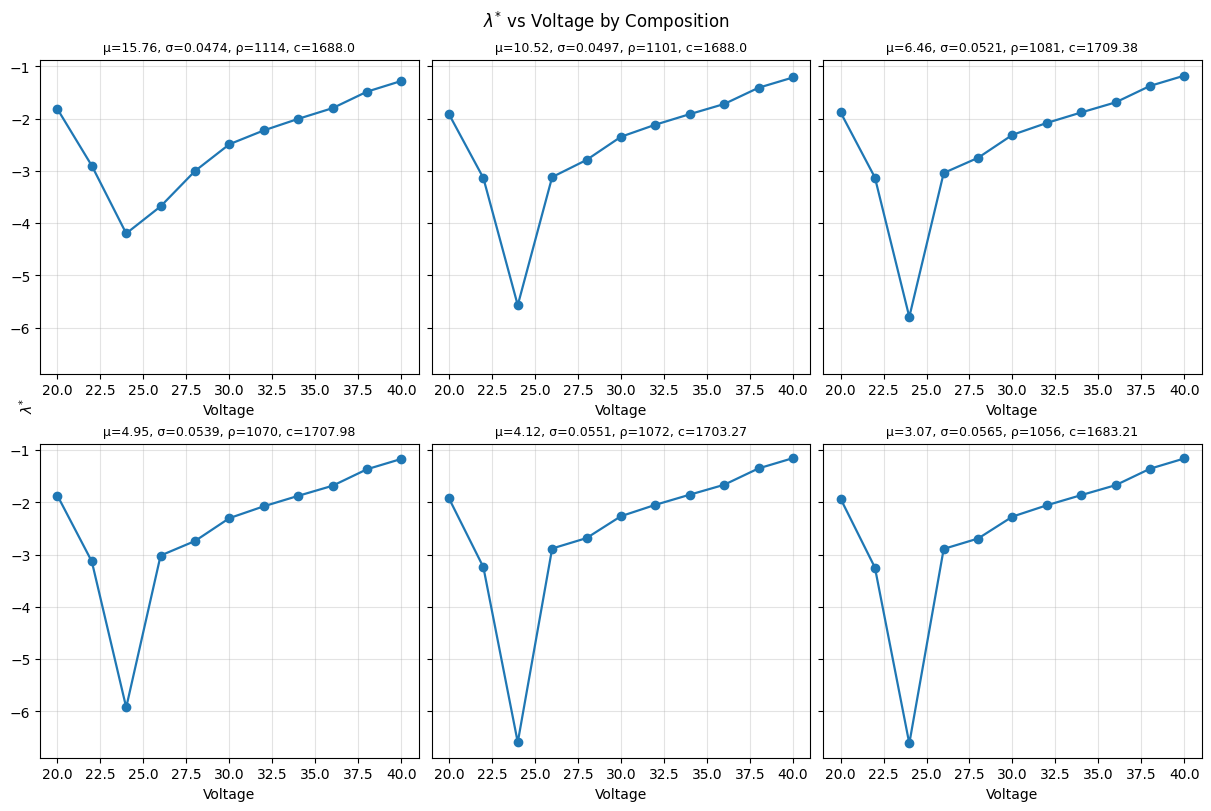

In [13]:
import io, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# 1) 제공된 표 데이터를 그대로 사용 (Dummy data 아님)
# ─────────────────────────────────────────────────────────────
data_str = """mu	sigma	rho	c	t	V_name
15.76	0.0474	1114	1688	118	v20
15.76	0.0474	1114	1688	121	v22
15.76	0.0474	1114	1688	122	v24
15.76	0.0474	1114	1688	130	v26
15.76	0.0474	1114	1688	123	v28
15.76	0.0474	1114	1688	122	v30
15.76	0.0474	1114	1688	123	v32
15.76	0.0474	1114	1688	123	v34
15.76	0.0474	1114	1688	122	v36
15.76	0.0474	1114	1688	120	v38
15.76	0.0474	1114	1688	128	v40
10.52	0.0497	1101	1688	118	v20
10.52	0.0497	1101	1688	121	v22
10.52	0.0497	1101	1688	122	v24
10.52	0.0497	1101	1688	130	v26
10.52	0.0497	1101	1688	123	v28
10.52	0.0497	1101	1688	122	v30
10.52	0.0497	1101	1688	123	v32
10.52	0.0497	1101	1688	123	v34
10.52	0.0497	1101	1688	122	v36
10.52	0.0497	1101	1688	120	v38
10.52	0.0497	1101	1688	128	v40
6.46	0.0521	1081	1709.38	118	v20
6.46	0.0521	1081	1709.38	121	v22
6.46	0.0521	1081	1709.38	122	v24
6.46	0.0521	1081	1709.38	130	v26
6.46	0.0521	1081	1709.38	123	v28
6.46	0.0521	1081	1709.38	122	v30
6.46	0.0521	1081	1709.38	123	v32
6.46	0.0521	1081	1709.38	123	v34
6.46	0.0521	1081	1709.38	122	v36
6.46	0.0521	1081	1709.38	120	v38
6.46	0.0521	1081	1709.38	128	v40
4.95	0.0539	1070	1707.98	118	v20
4.95	0.0539	1070	1707.98	121	v22
4.95	0.0539	1070	1707.98	122	v24
4.95	0.0539	1070	1707.98	130	v26
4.95	0.0539	1070	1707.98	123	v28
4.95	0.0539	1070	1707.98	122	v30
4.95	0.0539	1070	1707.98	123	v32
4.95	0.0539	1070	1707.98	123	v34
4.95	0.0539	1070	1707.98	122	v36
4.95	0.0539	1070	1707.98	120	v38
4.95	0.0539	1070	1707.98	128	v40
4.12	0.0551	1072	1703.27	118	v20
4.12	0.0551	1072	1703.27	121	v22
4.12	0.0551	1072	1703.27	122	v24
4.12	0.0551	1072	1703.27	130	v26
4.12	0.0551	1072	1703.27	123	v28
4.12	0.0551	1072	1703.27	122	v30
4.12	0.0551	1072	1703.27	123	v32
4.12	0.0551	1072	1703.27	123	v34
4.12	0.0551	1072	1703.27	122	v36
4.12	0.0551	1072	1703.27	120	v38
4.12	0.0551	1072	1703.27	128	v40
3.07	0.0565	1056	1683.21	118	v20
3.07	0.0565	1056	1683.21	121	v22
3.07	0.0565	1056	1683.21	122	v24
3.07	0.0565	1056	1683.21	130	v26
3.07	0.0565	1056	1683.21	123	v28
3.07	0.0565	1056	1683.21	122	v30
3.07	0.0565	1056	1683.21	123	v32
3.07	0.0565	1056	1683.21	123	v34
3.07	0.0565	1056	1683.21	122	v36
3.07	0.0565	1056	1683.21	120	v38
3.07	0.0565	1056	1683.21	128	v40
"""
df = pd.read_csv(io.StringIO(data_str), sep=r"\s+")

# 전압 숫자 추출
def parse_voltage(vname: str) -> int:
    m = re.search(r"(\d+)", str(vname))
    if not m:
        raise ValueError(f"Invalid V_name: {vname}")
    return int(m.group(1))

df["Voltage"] = df["V_name"].map(parse_voltage)

# 조성별 그룹핑
group_keys = ["mu", "sigma", "rho", "c"]
groups = list(df.groupby(group_keys, sort=False))

# ─────────────────────────────────────────────────────────────
# 2) 플롯: 2×3 서브플롯, y축 라벨은 fig.text 로 중앙 배치
#    bo_objective, model, WAVE_DB, DEVICE 는 사용자 환경에 정의되어 있어야 함
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True, constrained_layout=True)
axes = axes.ravel()

# 시각화에 사용된 데이터 누적용 리스트
records = []

for ax, (comp, g) in zip(axes, groups):
    g_sorted = g.sort_values("Voltage")

    # rows: (mu, sigma, rho, c, t, V_name)
    rows = [(float(comp[0]), float(comp[1]), float(comp[2]), float(comp[3]),
             float(t), str(vn)) for t, vn in zip(g_sorted["t"], g_sorted["V_name"])]

    # λ* 계산
    lam_list = [bo_objective(cand, model, WAVE_DB, DEVICE) for cand in rows]
    volts    = g_sorted["Voltage"].to_numpy()

    # 플롯
    ax.plot(volts, lam_list, marker="o", linewidth=1.6)
    ax.set_xlabel("Voltage")
    ax.grid(True, alpha=0.35)
    ax.set_title(f"μ={comp[0]}, σ={comp[1]}, ρ={comp[2]}, c={comp[3]}", fontsize=9)

    # 콘솔로 각 조성의 최소값 보고
    idx_min = int(np.argmin(lam_list))
    print(f"[Comp μ={comp[0]}, σ={comp[1]}, ρ={comp[2]}, c={comp[3]}] "
          f"min λ*={lam_list[idx_min]:+.3e} @ V={volts[idx_min]} (wave={rows[idx_min][-1]})")

    # CSV 저장용 레코드 누적
    for lam, vol, row in zip(lam_list, volts, rows):
        records.append({
            "mu": comp[0], "sigma": comp[1], "rho": comp[2], "c": comp[3],
            "t": row[4], "V_name": row[5], "Voltage": int(vol),
            "lambda_star": float(lam)
        })

# 공통 Y라벨(요청: fig.text 사용)
fig.text(0.01, 0.5, r"$\lambda^{*}$", va="center", rotation=90)
fig.suptitle(r"$\lambda^{*}$ vs Voltage by Composition", fontsize=12)

# ─────────────────────────────────────────────────────────────
# 3) 시각화에 사용된 데이터 CSV로 저장
#    - 전체 곡선 데이터: lambda_vs_voltage_by_composition.csv
#    - 조성별 최소값 요약: lambda_min_by_composition.csv
# ─────────────────────────────────────────────────────────────
out_dir = os.path.join(os.getcwd(), "export_lambda")
os.makedirs(out_dir, exist_ok=True)

df_plot = pd.DataFrame.from_records(records)
df_plot = df_plot.sort_values(["mu", "sigma", "rho", "c", "Voltage"]).reset_index(drop=True)
df_plot.to_csv(os.path.join(out_dir, "lambda_vs_voltage_by_composition.csv"),
               index=False, encoding="utf-8-sig")

idxmin = df_plot.groupby(["mu", "sigma", "rho", "c"])["lambda_star"].idxmin()
df_min = df_plot.loc[idxmin].copy().sort_values(["mu", "sigma", "rho", "c"]).reset_index(drop=True)
df_min = df_min.rename(columns={"Voltage": "min_voltage", "lambda_star": "min_lambda_star"})
df_min.to_csv(os.path.join(out_dir, "lambda_min_by_composition.csv"),
              index=False, encoding="utf-8-sig")

plt.show()


### Result 4. Gaussian Process-Based Procedure for Extended Bayesian Optimization

In [20]:
true_lambda = np.array([bo_objective(r, model, WAVE_DB, DEVICE) for r in rows])

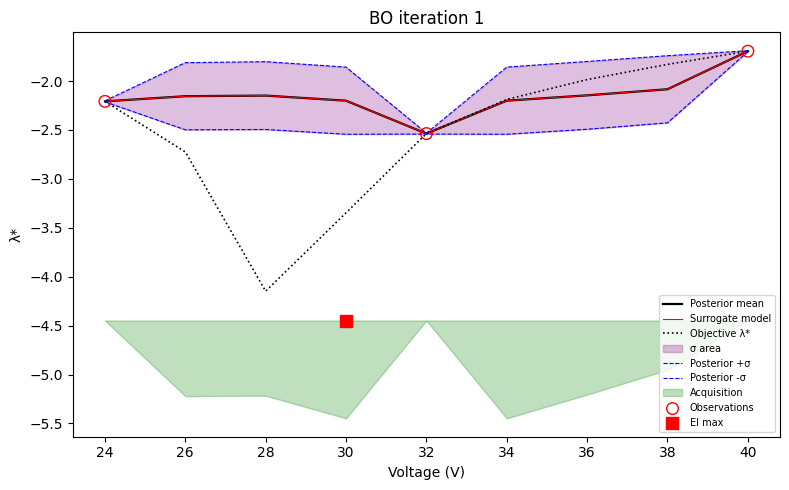

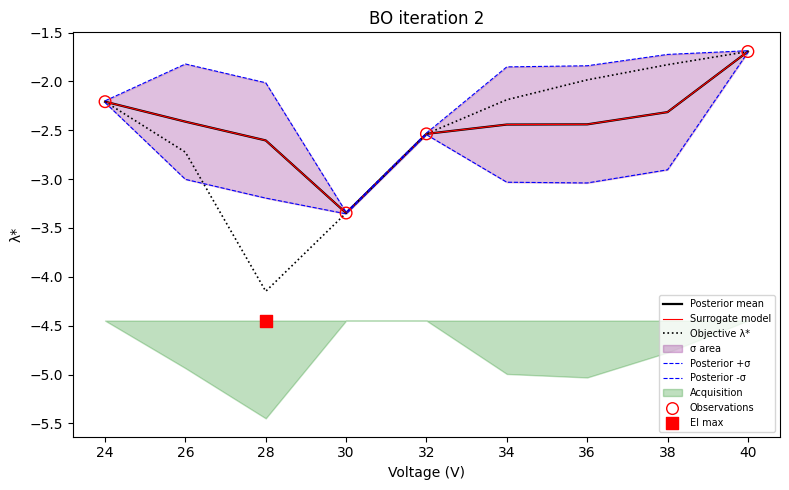

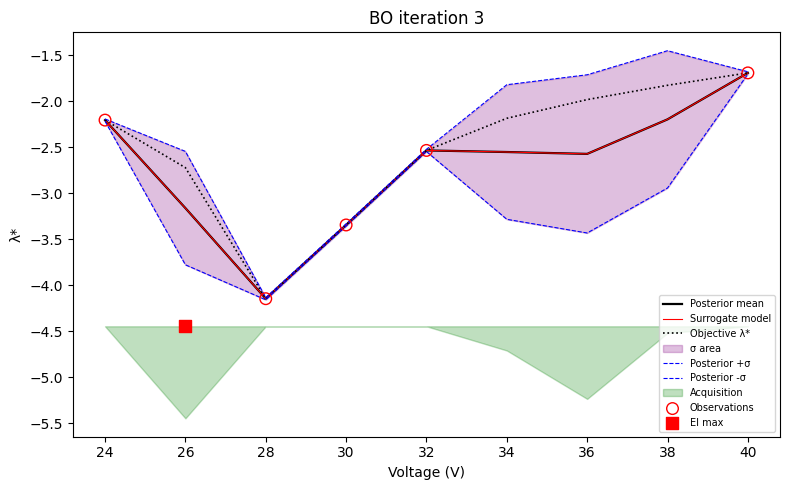

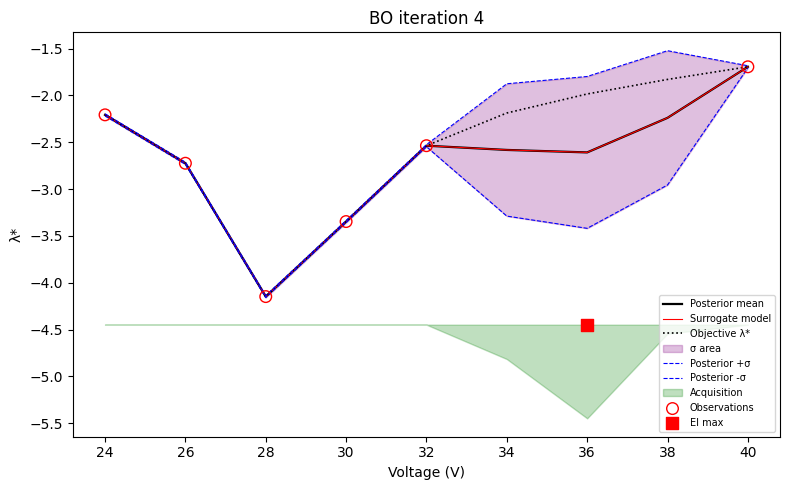

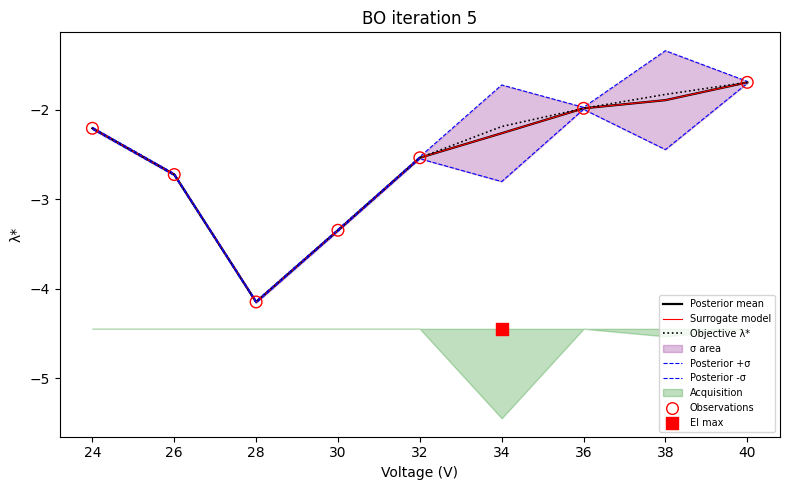

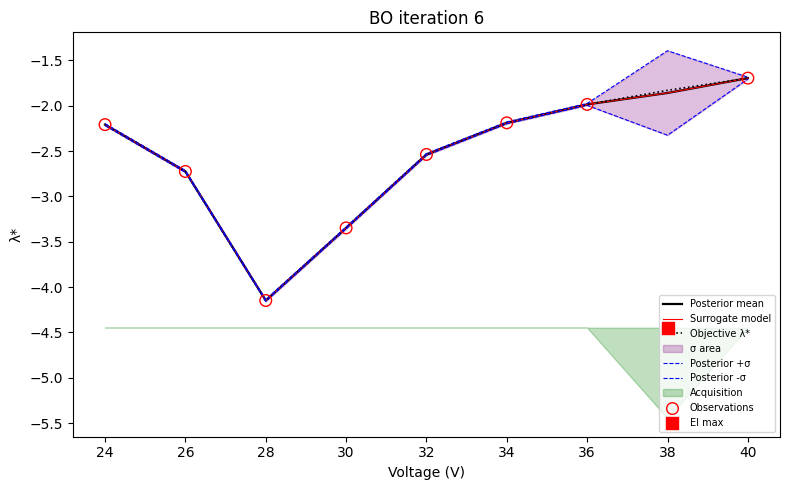

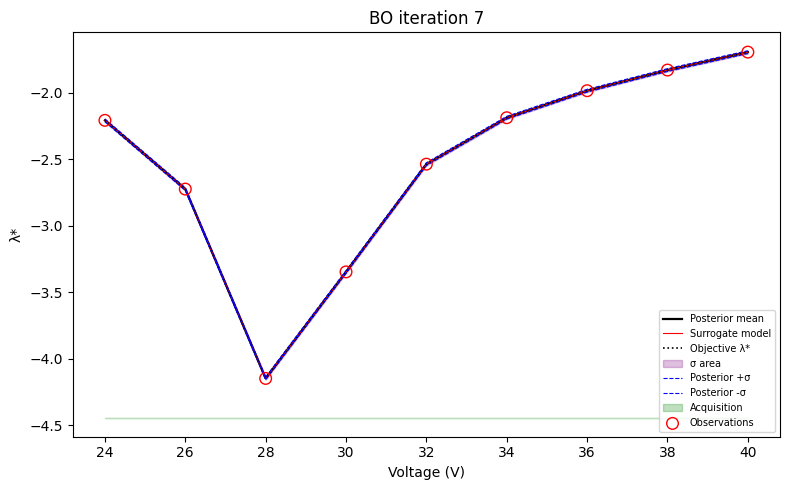

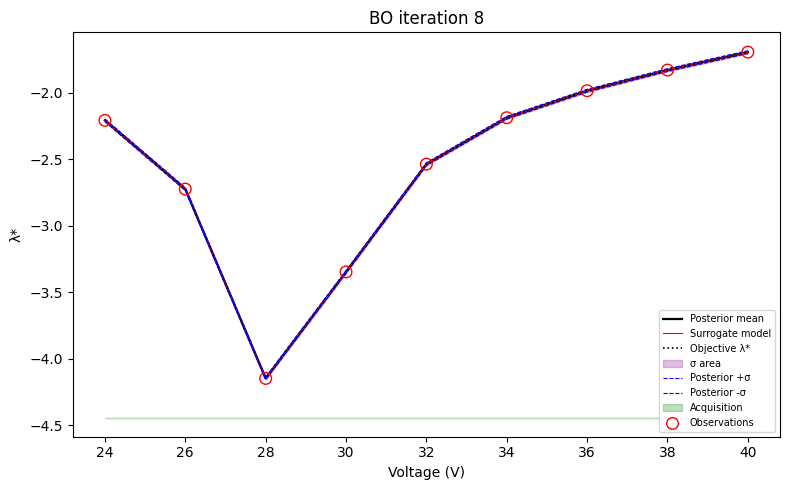

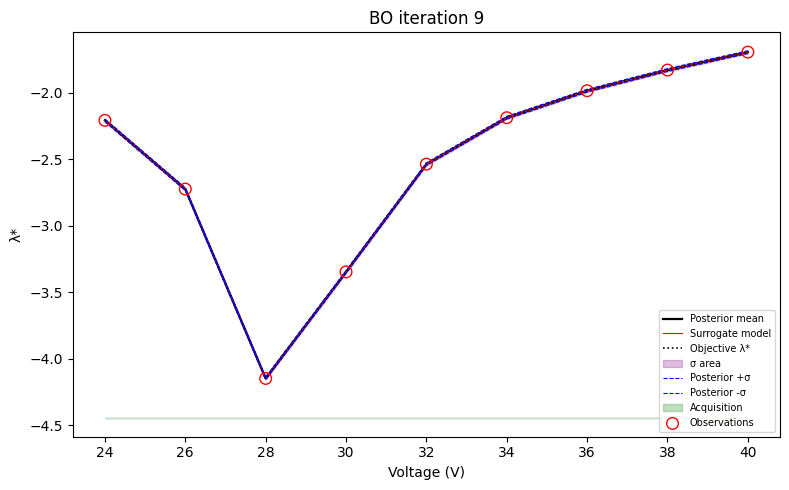

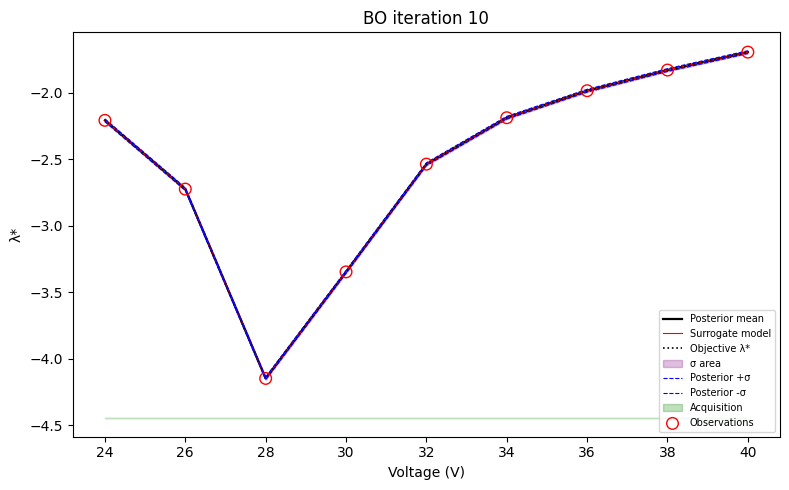

In [21]:
import re, numpy as np, matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.stats import norm        # EI 계산용 CDF/PDF

# ============================================================
# 0. 데이터 준비  ─ rows : ( … , wave_id )
# ============================================================
rows = [
    (15.76,0.0474,1114,1679.5,120,"v24"),
    (15.76,0.0474,1114,1679.5,121,"v26"),
    (15.76,0.0474,1114,1679.5,122,"v28"),
    (15.76,0.0474,1114,1679.5,123,"v30"),
    (15.76,0.0474,1114,1679.5,124,"v32"),
    (15.76,0.0474,1114,1679.5,125,"v34"),
    (15.76,0.0474,1114,1679.5,126,"v36"),
    (15.76,0.0474,1114,1679.5,127,"v38"),
    (15.76,0.0474,1114,1679.5,128,"v40"),
]

# --- 전압[V] 추출 → GP 입력 X --------------------------------
voltage_grid = np.array([int(re.sub(r"\D","", r[5])) for r in rows],  ### NEW ###
                        dtype=float).reshape(-1,1)                   # (9,1)

# true_lambda : 각 행에 대한 λ* (이미 계산해 둔다고 가정)
# e.g. true_lambda = np.array([...])  # shape (9,)

# ============================================================
# 1. GP 커널
# ============================================================
kernel = (ConstantKernel(1.0,(1e-2,1e2))
          * Matern(length_scale=1.0,nu=2.5)
          + WhiteKernel(noise_level=1e-4))

# ============================================================
# 2. 초기 관측 – 전압 24 V, 32 V, 40 V  (index 0,4,8)
# ============================================================
init_idx = [0,4,8]
obs_mask = np.zeros(len(rows),bool)
obs_mask[init_idx] = True

max_iter = 10
for it in range(max_iter):
    # --------------------------------------------------------
    # (1) GP 학습
    # --------------------------------------------------------
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
    gp.fit(voltage_grid[obs_mask],          # X_obs : (n_obs,1)   
           true_lambda[obs_mask])           # y_obs

    mu, std = gp.predict(voltage_grid, return_std=True)  

    # --------------------------------------------------------
    # (2) Expected Improvement
    # --------------------------------------------------------
    f_best = true_lambda[obs_mask].min()
    sigma  = np.maximum(std, 1e-9)
    z = (f_best - mu)/sigma
    ei = (f_best - mu)*norm.cdf(z) + sigma*norm.pdf(z)
    ei[obs_mask] = 0.0
    ei_norm = ei / (ei.max() + 1e-12)

    # --------------------------------------------------------
    # (3) 시각화
    # --------------------------------------------------------
    plt.figure(figsize=(8,5))

    plt.plot(voltage_grid, mu, 'k-', lw=1.6, label='Posterior mean')
    plt.plot(voltage_grid, mu, 'r-', lw=0.8, label='Surrogate model')
    plt.plot(voltage_grid, true_lambda, 'k:', lw=1.2, label='Objective λ*')

    plt.fill_between(voltage_grid.flatten(), mu-std, mu+std,
                     color='purple', alpha=0.25, label='σ area')
    plt.plot(voltage_grid, mu+std, 'b--', lw=0.8, label='Posterior +σ')
    plt.plot(voltage_grid, mu-std, 'b--', lw=0.8, label='Posterior -σ')

    ei_offset = true_lambda.min() - 0.3
    plt.fill_between(voltage_grid.flatten(), ei_offset,
                     ei_offset - ei_norm,
                     color='green', alpha=0.25, label='Acquisition')

    plt.scatter(voltage_grid[obs_mask], true_lambda[obs_mask],
                facecolors='none', edgecolors='red', s=70,
                zorder=5, label='Observations')

    if (~obs_mask).any():
        next_idx = int(np.argmax(ei))
        plt.scatter(voltage_grid[next_idx], ei_offset, marker='s',
                    color='red', s=80, zorder=6, label='EI max')

    plt.xlabel('Voltage (V)')               ### NEW ###
    plt.ylabel('λ*')
    plt.title(f'BO iteration {it+1}')
    plt.legend(loc='lower right', fontsize=7)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # (4) 관측 집합 업데이트
    # --------------------------------------------------------
    if (~obs_mask).any():
        obs_mask[next_idx] = True
